In [1]:
import cv2
import numpy as np
import scipy
from matplotlib import pyplot as plt
import math
from sklearn import svm, metrics

## Task 1

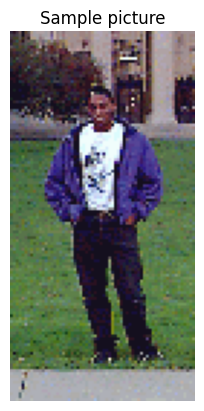

In [2]:
I = cv2.imread("pedestrians/pos/per00060.ppm")
I_plot = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)
plt.imshow(I_plot)
plt.title("Sample picture")
plt.axis("off")
plt.show()

In [3]:
def task1_gradient(I):
    dx = scipy.ndimage.convolve1d(np.int32(I),np.array([-1, 0, 1]),1)
    dy = scipy.ndimage.convolve1d(np.int32(I),np.array([-1, 0, 1]),0)
    magnitude = np.sqrt(np.square(dx)+np.square(dy))
    max_B = np.logical_and(magnitude[:,:,1]<magnitude[:,:,0],magnitude[:,:,2]<magnitude[:,:,0])
    max_G = np.logical_and(magnitude[:,:,0]<magnitude[:,:,1],magnitude[:,:,2]<magnitude[:,:,1])
    max_R = np.logical_and(magnitude[:,:,0]<magnitude[:,:,2],magnitude[:,:,1]<magnitude[:,:,2])
    theta = np.rad2deg(b:=np.arctan2(dy,dx)) + 180.0 * (b<0)
    theta_res = np.zeros(I.shape[0:2],dtype = np.float32)
    theta_res[max_G] = theta[:,:,1][max_G]
    theta_res[max_B] = theta[:,:,0][max_B]
    theta_res[max_R] = theta[:,:,2][max_R]
    m = np.max(magnitude,axis=2)
    return m, theta_res

def task2_gradient(I, m, theta_res):
    cellSize = 8
    XX, YY = I.shape[0:2]
    
    YY_cell=np.int32(YY/cellSize)
    XX_cell=np.int32(XX/cellSize)
    histograms = np.zeros((XX_cell,YY_cell,9), dtype = np.float32)
    hist_middles = np.array(list(range(10,180,20)), dtype=np.float32)
    BW = 20.0
    for i in range(XX_cell):
        for j in range(YY_cell):
            theta_cut = theta_res[cellSize*i:cellSize*(i+1),cellSize*j:cellSize*(j+1)]
            m_cut = m[cellSize*i:cellSize*(i+1),cellSize*j:cellSize*(j+1)]
            for x in range(cellSize):
                for y in range(cellSize):
                    no_bucket1 = int(theta_cut[x,y]/20)%9
                    no_bucket2 = int((theta_cut[x,y]/20) + 0.5)%9
                    if no_bucket1 == no_bucket2:
                        no_bucket2 = int((theta_cut[x,y]/20) - 0.5) if ((theta_cut[x,y]/20) - 0.5) > 0 else 8
                    temp1 = (np.abs(hist_middles[no_bucket1] - theta_cut[x,y]) if np.abs(hist_middles[no_bucket1] - theta_cut[x,y])<=BW else np.abs(np.abs(hist_middles[no_bucket1] - theta_cut[x,y])-180))
                    temp2 = (np.abs(hist_middles[no_bucket2] - theta_cut[x,y]) if np.abs(hist_middles[no_bucket2] - theta_cut[x,y])<=BW else np.abs(np.abs(hist_middles[no_bucket2] - theta_cut[x,y])-180))
                    histograms[i,j,no_bucket1] += m_cut[x,y] * (temp2/BW)
                    histograms[i,j,no_bucket2] += m_cut[x,y] * (temp1/BW)
    
    # Normalization in block
    e = math.pow(0.00001 ,2)
    F = np.array([])
    for jj in range (0 , XX_cell -1) :
        for ii in range (0 , YY_cell -1) :
            H0 = histograms [ jj,ii,:]#[::-1]
            H1 = histograms [ jj  ,ii+1, :]#[::-1]
            H2 = histograms [  jj+1 ,ii  ,:]#[::-1]
            H3 = histograms [  jj +1 ,ii +1 ,:]#[::-1]
            H = np . concatenate (( H0 , H1 , H2 , H3 ))
            n = np . linalg . norm (H)
            Hn = H/ np . sqrt ( math . pow (n ,2) + e)
            F = np . concatenate ((F , Hn ))
    return F

def HOG(I):
    m, theta_res = task1_gradient(I)
    F = task2_gradient(I, m, theta_res)
    return F

In [4]:
m, theta_res = task1_gradient(I)
res = task2_gradient(I, m, theta_res)
for i in range(10):
    print(res[i])

0.3484171378042161
0.1594149188666196
0.10328233830958661
0.13048261835997843
0.13657353569178937
0.09067180979218818
0.08944646169195637
0.19259911473942742
0.1986123017500994
0.16416041099017395


## Task 2

In [5]:
HOG_data = np.zeros([2*100, 3781],np.float32)

for i in range(0, 100):
    IP = cv2.imread('pedestrians/pos/per%05d.ppm' % (i+1))
    IN = cv2.imread('pedestrians/neg/neg%05d.png' % (i+1))
    F = HOG(IP)
    HOG_data[i,0] = 1
    HOG_data[i,1:] = F
    F = HOG(IN)
    HOG_data[i+100,0] = 0
    HOG_data[i+100,1:] = F

In [6]:
labels = HOG_data[:,0]
data = HOG_data[:,1:]

In [7]:
clf = svm.SVC(kernel="linear", C=1.0)
clf.fit(data,labels)
lp = clf.predict(data)

In [8]:
metrics.confusion_matrix(labels,lp)

array([[100,   0],
       [  0, 100]])

### Test

In [9]:
HOG_data = np.zeros([2*100, 3781],np.float32)

for i in range(100, 200):
    IP = cv2.imread('pedestrians/pos/per%05d.ppm' % (i+1))
    IN = cv2.imread('pedestrians/neg/neg%05d.png' % (i+1))
    F = HOG(IP)
    HOG_data[i-100,0] = 1
    HOG_data[i-100,1:] = F
    F = HOG(IN)
    HOG_data[i,0] = 0
    HOG_data[i,1:] = F
lp = clf.predict(data)
metrics.confusion_matrix(labels,lp)

array([[100,   0],
       [  0, 100]])

## Task 3

In [10]:
def non_max_suppression(rectangles, overlap_thresh=0.3):
    if len(rectangles) == 0:
        return []

    if rectangles.dtype.kind == "i":
        rectangles = rectangles.astype("float")

    pick = []
    x1 = rectangles[:, 0]
    y1 = rectangles[:, 1]
    x2 = rectangles[:, 0] + rectangles[:, 2]
    y2 = rectangles[:, 1] + rectangles[:, 3]

    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(y2)

    while len(idxs) > 0:
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)

        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        overlap = (w * h) / area[idxs[:last]]

        idxs = np.delete(idxs, np.concatenate(([last], np.where(overlap > overlap_thresh)[0])))

    return rectangles[pick].astype("int")

def detect_pedestrians(image, svm, step_size=16, scale_factor=1.2, min_size=(64, 128)):
    rectangles = []
    original_image = image.copy()
    current_scale = 1.0
    resized_image = image.copy()

    while True:
        height, width = resized_image.shape[:2]
        if height < min_size[1] or width < min_size[0]:
            break

        for y in range(0, height - min_size[1] + 1, step_size):
            for x in range(0, width - min_size[0] + 1, step_size):
                window = resized_image[y:y + min_size[1], x:x + min_size[0]]
                hog_descriptor = HOG(window)
                prediction = svm.predict([hog_descriptor])
                if prediction == 1:
                    # Skaluje współrzędne wykrycia do rozmiaru oryginalnego obrazu
                    rect_x = int(x * current_scale)
                    rect_y = int(y * current_scale)
                    rect_w = int(min_size[0] * current_scale)
                    rect_h = int(min_size[1] * current_scale)
                    rectangles.append((rect_x, rect_y, rect_w, rect_h))

        # Pomniejsz obraz na kolejną iterację
        current_scale *= scale_factor
        new_width = int(image.shape[1] / current_scale)
        new_height = int(image.shape[0] / current_scale)
        if new_width < min_size[0] or new_height < min_size[1]:
            break
        resized_image = cv2.resize(image, (new_width, new_height))

    rectangles = np.array(rectangles)
    rectangles = non_max_suppression(rectangles)

    for (x, y, w, h) in rectangles:
        cv2.rectangle(original_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    return original_image

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: cHRM chunk does not match sRGB


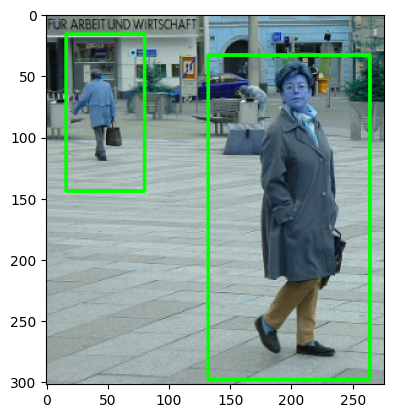

In [11]:
img = cv2.imread('test/testImage4.png')
img = cv2.resize(img,(int(img.shape[1]/1.2), int(img.shape[0]/1.2)))
plt.imshow(detect_pedestrians(img, clf,16,1.2))